In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg

from statsmodels.tsa.stattools import acf, pacf
%matplotlib inline

In [62]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)
df.head()

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


In [5]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [63]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [9]:
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}


<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

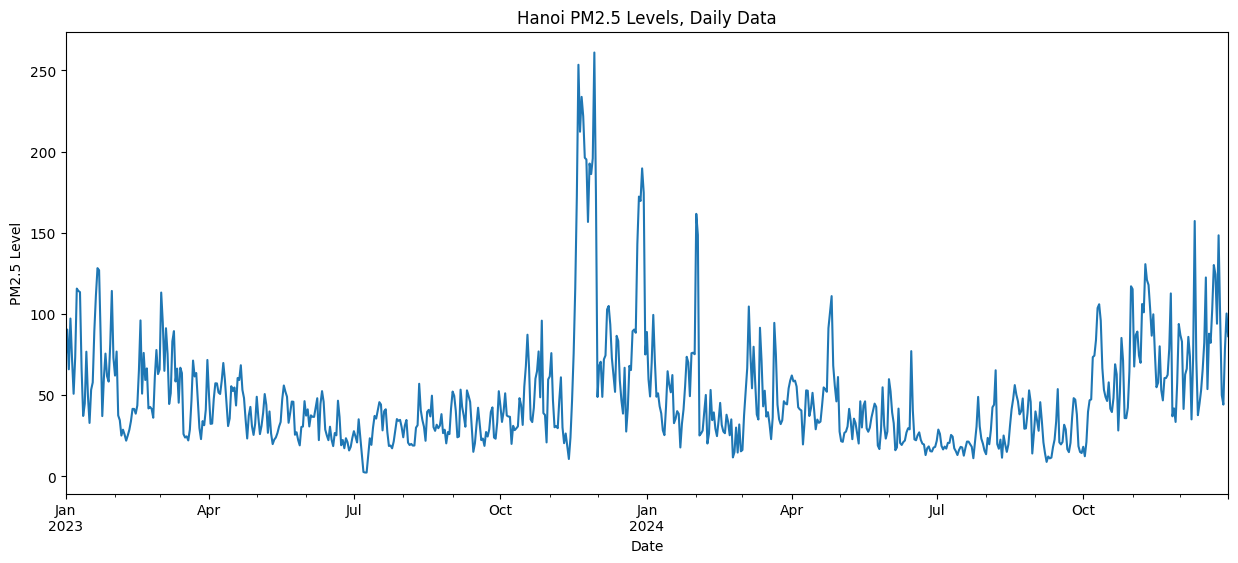

In [10]:

fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

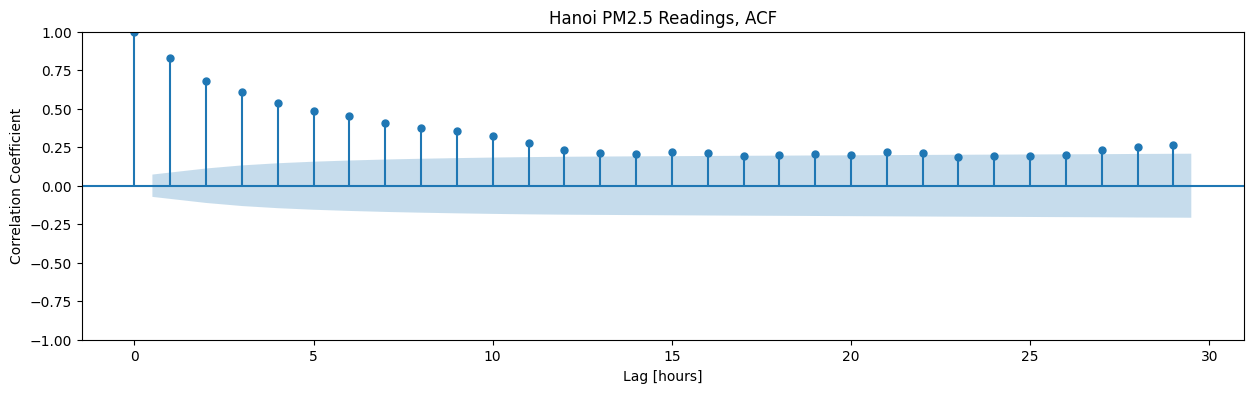

In [11]:

fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

In [39]:
# Tính toán giá trị ACF
acf_values = acf(df_pm25, nlags=30)
print("ACF Values:")
print(acf_values)
print()

ACF Values:
[1.         0.8318345  0.68120999 0.6071318  0.54026892 0.48526443
 0.4505717  0.40567924 0.37353712 0.35317632 0.32204188 0.27875251
 0.23205856 0.2097161  0.20668477 0.21699742 0.20990811 0.19037557
 0.20192397 0.2048931  0.200617   0.21692296 0.21362843 0.18756037
 0.1902888  0.19382632 0.20020349 0.23104868 0.25152455 0.26508183
 0.29204193]



**-> KẾT LUẬN:** Từ biểu đồ, chuỗi có tự tương quan mạnh ở các độ trễ (lag 1-5) -> giá trị Pm2.5 hôm nay ảnh hưởng mạnh ở các ngày trước đó. Chưa thể kết luận đc giá trị q

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

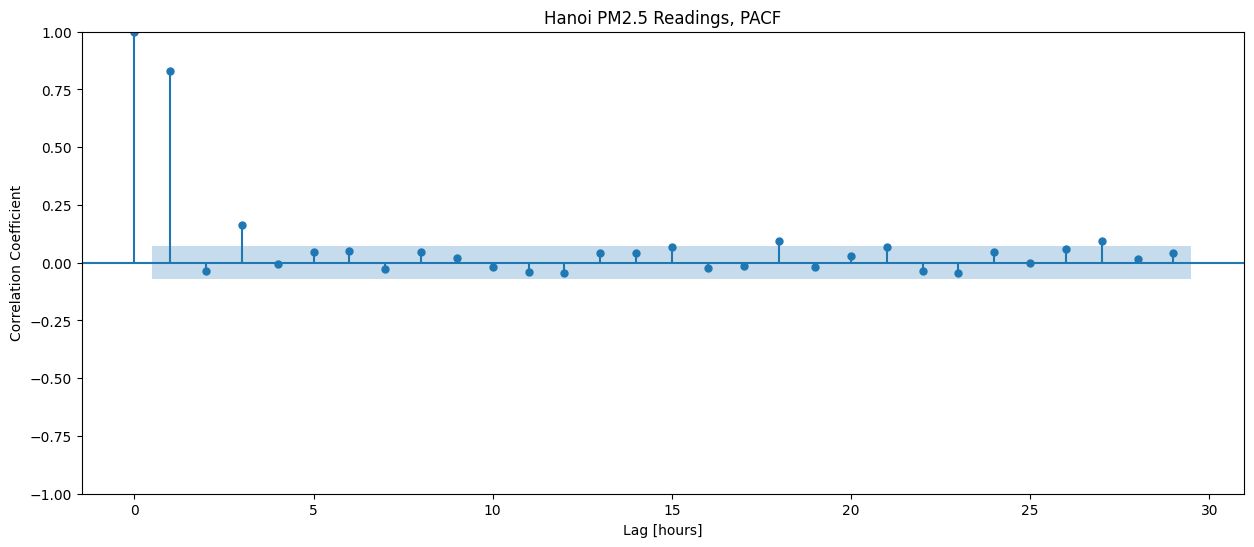

In [12]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

In [40]:
# Tính toán giá trị PACF
pacf_values = pacf(df_pm25, nlags=30)
print("PACF Values:")
print(pacf_values)

PACF Values:
[ 1.00000000e+00  8.32973997e-01 -3.51678932e-02  1.63291732e-01
 -5.85967474e-03  4.81100217e-02  4.97739613e-02 -2.55543469e-02
  4.72872127e-02  2.24349446e-02 -1.76001063e-02 -4.02010456e-02
 -4.57013655e-02  4.52583172e-02  4.27404266e-02  6.95492475e-02
 -2.20388165e-02 -1.49361272e-02  9.62861783e-02 -1.84846989e-02
  2.92705834e-02  7.25379651e-02 -3.54955336e-02 -4.40180356e-02
  4.89532070e-02  1.75789400e-04  6.04765775e-02  1.00863504e-01
  1.83581470e-02  4.40824720e-02  7.35591644e-02]


Biểu đồ PACF của chuỗi PM2.5 cho thấy hai độ trễ đầu (lag 1 và lag 2) có giá trị tương quan riêng phần rất cao và vượt ra ngoài vùng tin cậy, trong khi các độ trễ còn lại đều nằm trong phạm vi tin cậy và dao động quanh 0. Điều này cho thấy thành phần AR trong mô hình nên có bậc p = 2. Việc PACF “cắt cụt” sau lag 2 là đặc điểm điển hình của mô hình AR(2).

In [64]:
int(len(df_pm25))*0.8

584.8000000000001

In [15]:
cutoff_test = int(len(df_pm25)* 0.8) 
df_pm25_train = df_pm25.iloc[:cutoff_test]
df_pm25_test = df_pm25.iloc[cutoff_test:]
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)

df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


In [16]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.830512605524053
p-value: 3.985322860994825e-07
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


In [43]:
# 1. Tính giá trị trung bình của tập huấn luyện (training set)
df_pm25_train_mean = df_pm25_train.mean()

# 2. Tạo một danh sách dự đoán. 
#    Mô hình cơ sở này chỉ dự đoán "giá trị trung bình" lặp đi lặp lại.
#    Số lần dự đoán bằng đúng số lượng dữ liệu trong tập kiểm thử (test set).
df_pm25_pred_baseline = [df_pm25_train_mean] * len(df_pm25_test)

# 3. Tính Lỗi tuyệt đối trung bình (MAE) của mô hình cơ sở
#    Bằng cách so sánh dữ liệu "thực tế" (df_pm25_test) 
#    với dữ liệu "dự đoán" (df_pm25_pred_baseline)
mae_baseline = mean_absolute_error(df_pm25_test, df_pm25_pred_baseline)

# 4. In ra giá trị PM2.5 trung bình (đã làm tròn 2 chữ số)
print("Giá trị PM2.5 trung bình:", round(df_pm25_train_mean, 2))

# 5. In ra MAE của mô hình cơ sở (đã làm tròn 2 chữ số)
print("MAE của mô hình cơ sở (Baseline MAE):", round(mae_baseline, 2))

Giá trị PM2.5 trung bình: 47.51
MAE của mô hình cơ sở (Baseline MAE): 16.58


Mô hình cơ sở của bạn đoán: "Tôi đoán mọi ngày đều là 47.51."

Kết quả là: "Cách đoán đó, trung bình, đã sai 22.86."

MAE: Lỗi tuyệt đối trung bình (Mean Absolute Error)
- Trung bình các dự đoán sai lệch bao niêu so với thực tế
B1: Tính Lỗi (Error) Thưc tế - dự đoan
b2: Lỗi tuyệt đối: Trị tuyệt đối các giá trị tính ở B1
B3: Cộng tất cả chia trung bình

Nhận xét:
- Baseline = "Dự doán bằng giá trị trung bình"

In [18]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

[Dẫn chứng về tính chu kỳ của Pm25](https://www.sciencedirect.com/science/article/pii/S1309104215305456)

In [19]:
mae_grid = {}          # {p: [MAE(q0), MAE(q1), ...]}
aic_grid = {}          # {p: [AIC(q0), AIC(q1), ...]}
best = {"order": None, "MAE": float("inf"), "AIC": float("inf")}

for p in p_params:
    mae_grid[p] = []
    aic_grid[p] = []
    for q in q_params:
        order = (p, 0, q)   # d = 0 vì ADF cho thấy dừng
        try:
            t0 = time.time()
            model = ARIMA(
                df_pm25_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            elapsed = round(time.time() - t0, 2)
            print(f"Trained ARIMA{order} in {elapsed}s (AIC={model.aic:.2f}).")

            # In-sample prediction - dùng fittedvalues an toàn hơn
            yhat = model.fittedvalues

            mae = mean_absolute_error(df_pm25_train[len(df_pm25_train) - len(yhat):], yhat)
            mae_grid[p].append(mae)
            aic_grid[p].append(model.aic)

            # Cập nhật best theo AIC (khuyến nghị)
            if model.aic < best["AIC"]:
                best = {"order": order, "MAE": mae, "AIC": model.aic}

        except Exception as e:
            print(f"Skip ARIMA{order}: {e}")
            mae_grid[p].append(None)
            aic_grid[p].append(None)

print("\n" + "="*50)
print("Best model by AIC:", best)
print("="*50)
print("\nMAE grid:", mae_grid)
print("\nAIC grid:", aic_grid)

Trained ARIMA(0, 0, 0) in 0.08s (AIC=5808.19).
Trained ARIMA(0, 0, 1) in 0.07s (AIC=5353.32).
Trained ARIMA(0, 0, 2) in 0.07s (AIC=5203.53).
Trained ARIMA(1, 0, 0) in 0.02s (AIC=5065.06).
Trained ARIMA(1, 0, 1) in 0.05s (AIC=5055.39).
Trained ARIMA(1, 0, 2) in 0.07s (AIC=5036.22).
Trained ARIMA(2, 0, 0) in 0.02s (AIC=5056.38).
Trained ARIMA(2, 0, 1) in 0.16s (AIC=5048.42).
Trained ARIMA(2, 0, 2) in 0.12s (AIC=5037.66).
Trained ARIMA(3, 0, 0) in 0.03s (AIC=5038.84).
Trained ARIMA(3, 0, 1) in 0.09s (AIC=5037.30).
Trained ARIMA(3, 0, 2) in 0.33s (AIC=5031.82).
Trained ARIMA(4, 0, 0) in 0.02s (AIC=5027.83).
Trained ARIMA(4, 0, 1) in 0.11s (AIC=5028.57).
Trained ARIMA(4, 0, 2) in 0.46s (AIC=5025.62).
Trained ARIMA(5, 0, 0) in 0.05s (AIC=5018.94).
Trained ARIMA(5, 0, 1) in 0.26s (AIC=5020.33).
Trained ARIMA(5, 0, 2) in 0.41s (AIC=5019.42).
Trained ARIMA(6, 0, 0) in 0.04s (AIC=5011.45).
Trained ARIMA(6, 0, 1) in 0.2s (AIC=5012.51).
Trained ARIMA(6, 0, 2) in 0.28s (AIC=5014.51).
Trained ARIMA(

In [47]:
# Sau khi chạy grid search
mae_df = pd.DataFrame(mae_grid)
aic_df = pd.DataFrame(aic_grid)

print("\nMAE Grid:")
print(mae_df.round(2))
print("\nAIC Grid:")
print(aic_df.round(2))




MAE Grid:
       0      1      2      3      4      5      6      7
0  22.84  12.49  12.49  12.33  12.36  12.33  12.30  12.29
1  16.30  12.50  12.43  12.35  12.34  12.33  12.24  12.25
2  14.40  12.33  12.35  12.39  12.48  12.37  12.24  12.55

AIC Grid:
         0        1        2        3        4        5        6        7
0  5808.19  5065.06  5056.38  5038.84  5027.83  5018.94  5011.45  5004.41
1  5353.32  5055.39  5048.42  5037.30  5028.57  5020.33  5012.51  5006.42
2  5203.53  5036.22  5037.66  5031.82  5025.62  5019.42  5014.51  4998.13


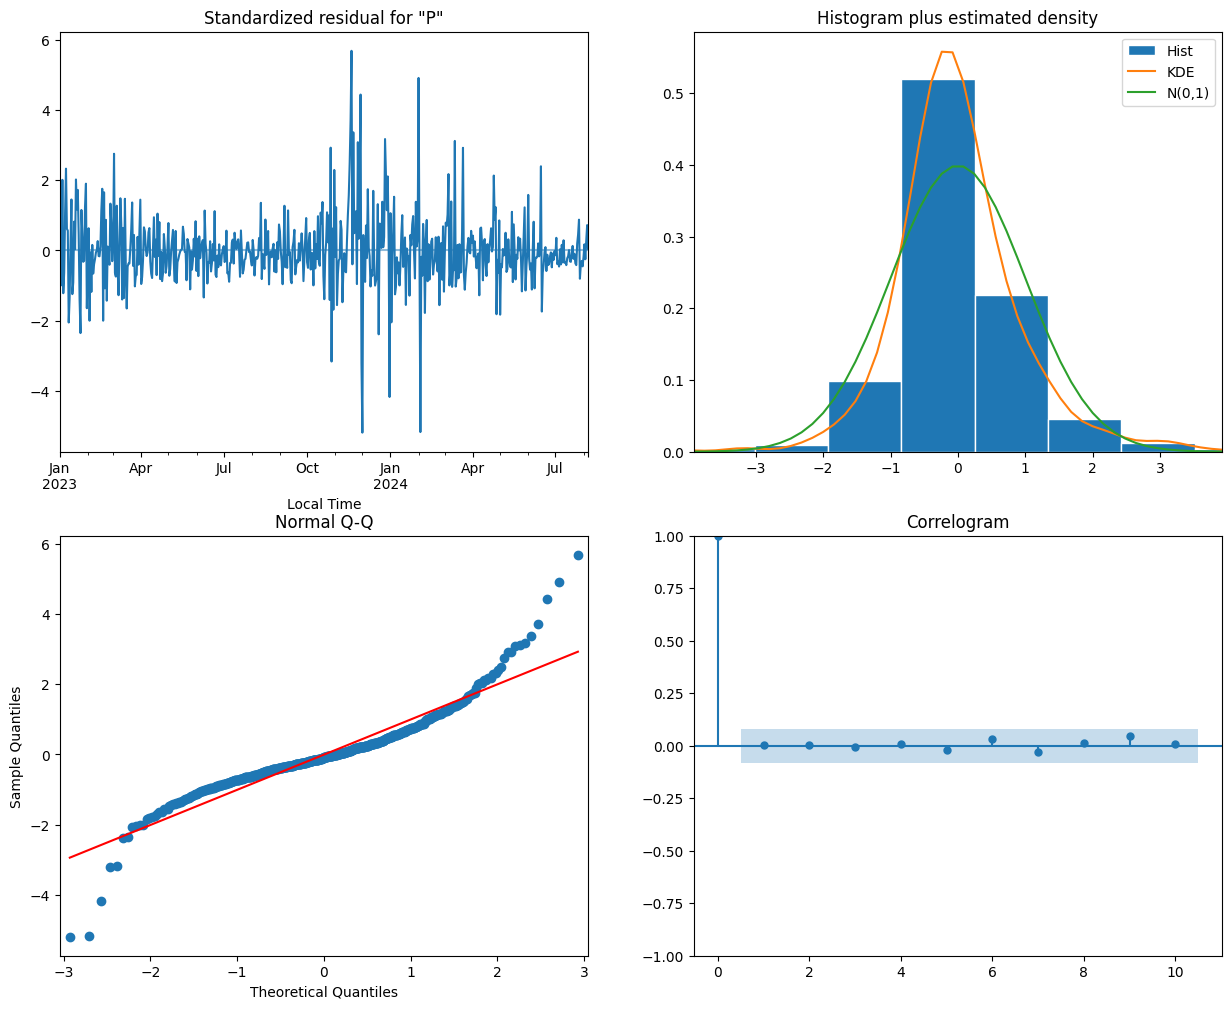

In [54]:
model = ARIMA(df_pm25_train, order=(7,0,2))
results = model.fit()
results.plot_diagnostics(figsize=(15,12))
plt.show()



In [23]:
df_pm25_pred_wfv = pd.Series()
history = df_pm25_train.copy()
for i in range(len(df_pm25_test)):
    model = ARIMA(history, order = (7, 0, 2)).fit()
    next_pred = model.forecast()
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    history = pd.concat([history, df_pm25_test[next_pred.index]])

C:\Users\hungd\AppData\Local\Temp\ipykernel_14720\776910693.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])


In [24]:
df_pm25_pred_wfv

2024-08-07    39.44
2024-08-08    64.86
2024-08-09    14.37
2024-08-10    28.95
2024-08-11    20.28
              ...  
2024-12-27    79.92
2024-12-28    64.47
2024-12-29    50.18
2024-12-30    75.22
2024-12-31    91.98
Freq: D, Length: 147, dtype: float64

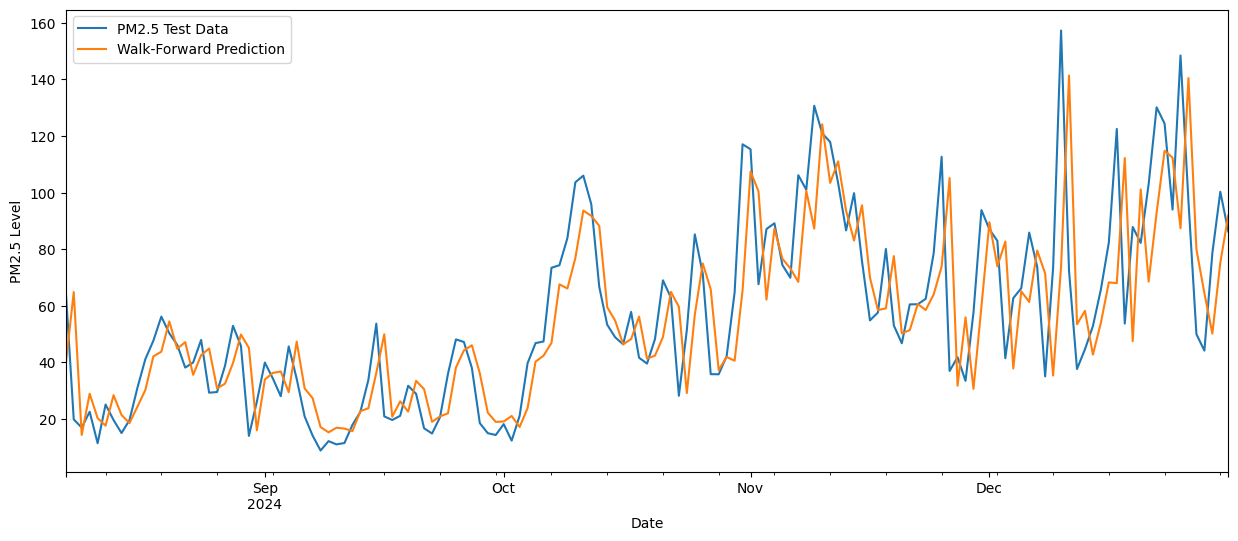

In [25]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()

c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is ava

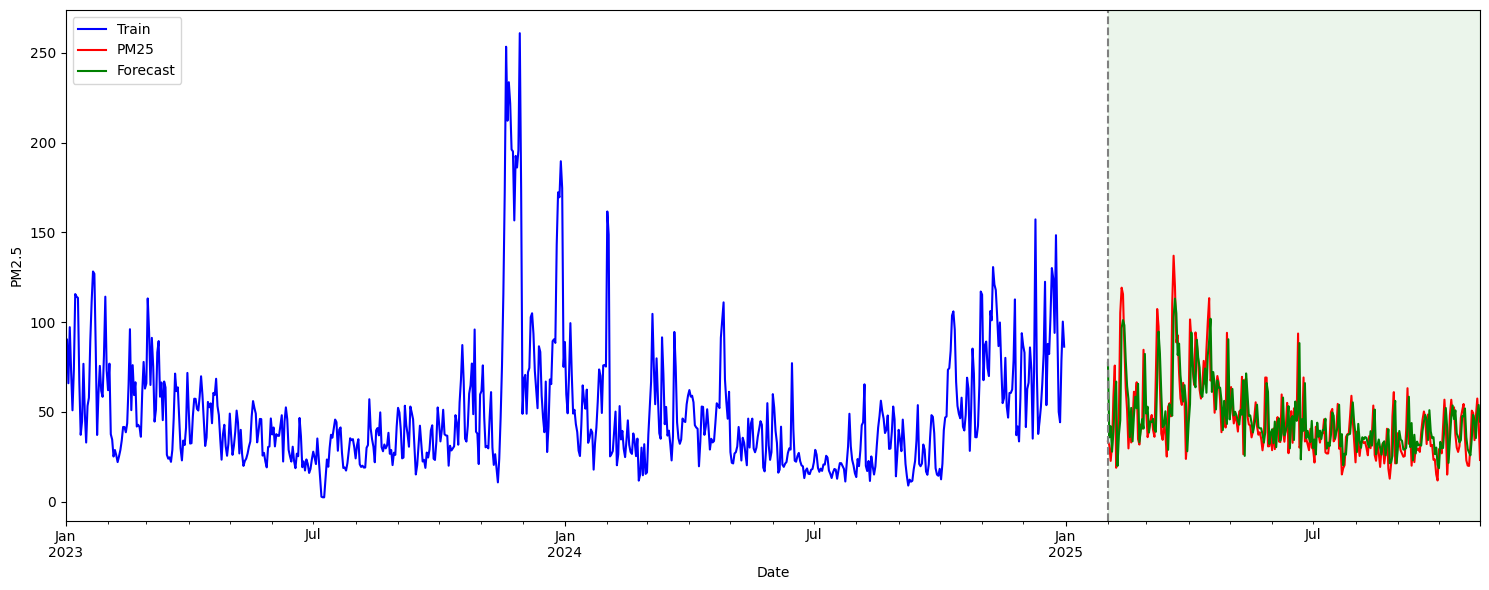

In [67]:
y_train = df_pm25.astype(float)
y_test  = df_pm25_test.astype(float)

y_pred = pd.Series(index=y_test.index, dtype=float, name="WFV_Pred")
history = y_train.copy()

for i in range(len(y_test)):
    model = ARIMA(history, order=(7,0,2), 
                  enforce_stationarity=False, enforce_invertibility=False).fit()
    next_fc = model.forecast(steps=1)
    y_pred.iloc[i] = float(next_fc.iloc[0])              # ghi đúng vị trí i
    history = pd.concat([history, y_test.iloc[i:i+1]])   # cập nhật bằng giá trị THẬT

# vẽ
ax = y_train.plot(label='Train', figsize=(15,6), color='blue')
y_test.plot(ax=ax, label='Test', color='red')
y_pred.plot(ax=ax, label='Forecast', color='green')
ax.axvline(y_test.index[0], ls='--', c='gray')
ax.axvspan(y_test.index[0], y_test.index[-1], color='green', alpha=0.08)
ax.set_ylabel('PM2.5'); ax.set_xlabel('Date'); ax.legend(); plt.tight_layout(); plt.show()

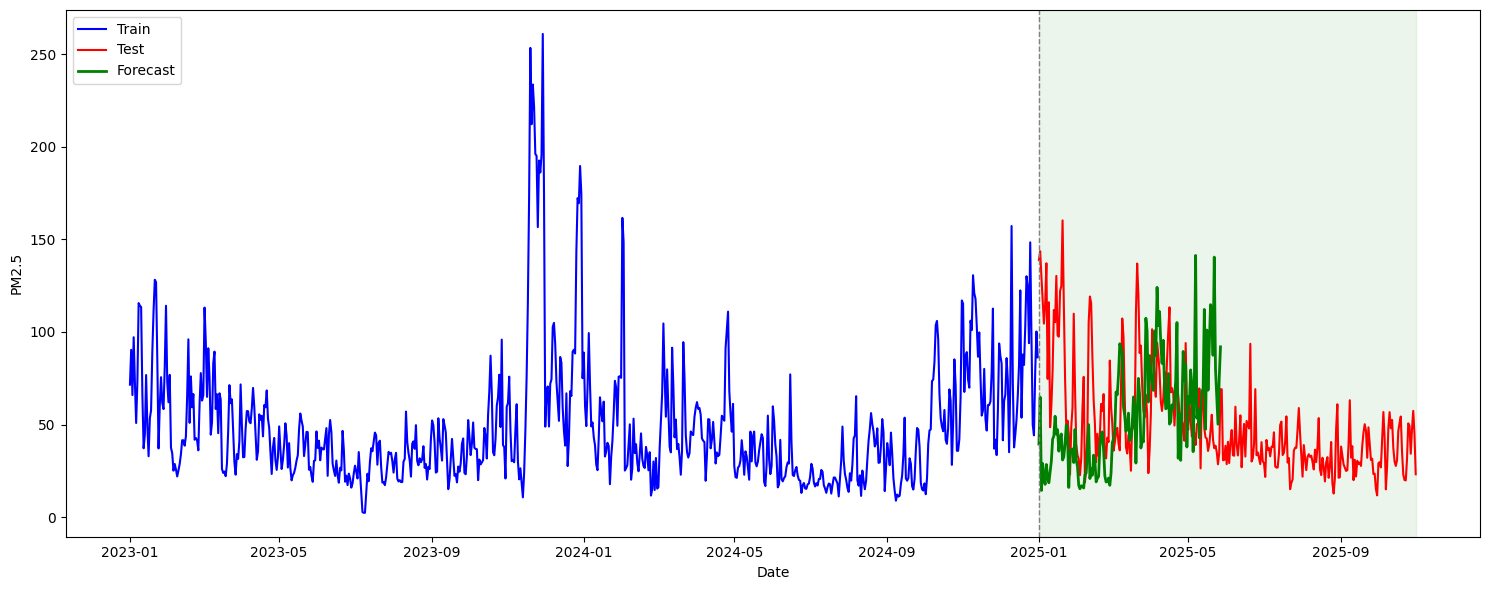

In [70]:
plt.figure(figsize=(15,6))

ax = plt.gca()   # lấy trục chính

# --- PLOT TRAIN ---
ax.plot(df_pm25.index, df_pm25.values, label='Train', color='blue', linewidth=1.5)
# --- PLOT TEST ---
ax.plot(df_pm25_test.index, df_pm25_test.values,label='Test', color='red', linewidth=1.5)
        

# --- ALIGN FORECAST INDEX ---
df_pm25_pred_wfv = df_pm25_pred_wfv.copy()
df_pm25_pred_wfv.index = df_pm25_test.index[:len(df_pm25_pred_wfv)]

# --- PLOT FORECAST ---
ax.plot(df_pm25_pred_wfv.index, df_pm25_pred_wfv.values, label='Forecast', color='green', linewidth=2)
      

# --- Gạch đường phân cách Train/Test ---
split = df_pm25_test.index[0]
ax.axvline(split, color='gray', linestyle='--', linewidth=1)

# --- Tô màu vùng Test ---
ax.axvspan(df_pm25_test.index[0],
           df_pm25_test.index[-1],
           color='green', alpha=0.08)

# --- Custom ---
# plt.title(f"ARIMA(7,0,2) - Walk-Forward Forecast\nTest MAE = {mae_wfv:.2f}",
#           fontsize=14)
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
df_pm25_test

,PM25
Local Time,
2025-02-01,33.465000
2025-02-02,31.416250
2025-02-03,22.632083
2025-02-04,31.446667
2025-02-05,58.430417
...,...
2025-10-27,34.200833
2025-10-28,47.288333
2025-10-29,57.395417


Test MAE: 25.94


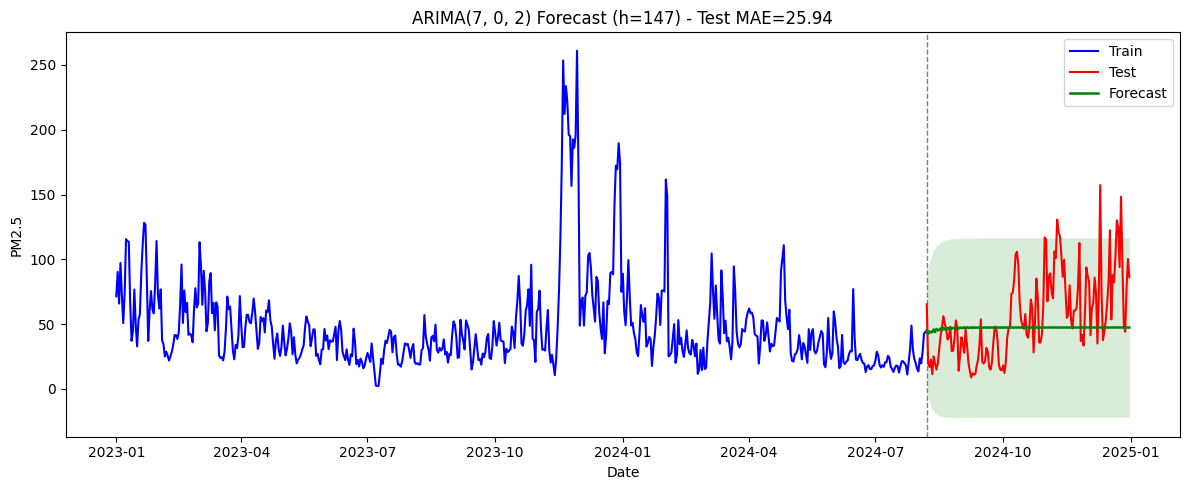

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

# 1) Fit trên TRAIN
best_order = (7, 0, 2)  # hoặc (6,0,1) nếu bạn chọn theo MAE
model = ARIMA(
    df_pm25_train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# 2) Forecast đa bước bằng độ dài TEST
h = len(df_pm25_test)
fc_res = model.get_forecast(steps=h)
y_fc = pd.Series(fc_res.predicted_mean, index=df_pm25_test.index)  # căn index cho khớp test
ci = fc_res.conf_int(alpha=0.05)  # khoảng tin cậy 95%
ci.index = df_pm25_test.index

# 3) Tính MAE trên TEST (so với baseline nếu muốn)
mae_test = mean_absolute_error(df_pm25_test, y_fc)
print("Test MAE:", round(mae_test, 2))

# 4) Vẽ biểu đồ
plt.figure(figsize=(12,5))

# Train
plt.plot(df_pm25_train.index, df_pm25_train.values, color='blue', label='Train', linewidth=1.5)

# Vạch chia train/test
split_date = df_pm25_test.index[0]
plt.axvline(split_date, color='gray', linestyle='--', linewidth=1)

# Test (ground truth)
plt.plot(df_pm25_test.index, df_pm25_test.values, color='red', label='Test', linewidth=1.5)

# Forecast
plt.plot(y_fc.index, y_fc.values, color='green', label='Forecast', linewidth=1.8)

# (tuỳ chọn) tô khoảng tin cậy
plt.fill_between(
    ci.index,
    ci.iloc[:, 0].values,  # lower
    ci.iloc[:, 1].values,  # upper
    alpha=0.15, color='green', linewidth=0
)

plt.title(f'ARIMA{best_order} Forecast (h={h}) - Test MAE={mae_test:.2f}')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error

history = df_pm25_train.copy()  # Khởi tạo history
preds, actuals = [], []

for i in range(len(df_pm25_test) - 3):
    # Train model với history hiện tại
    model = ARIMA(history, order=(7, 0, 2)).fit()

    # Dự báo 3 bước tiếp theo
    forecast = model.forecast(steps=3)

    # Lấy giá trị dự báo cho bước thứ 3 (index 2)
    preds.append(forecast.iloc[2])

    # Lấy giá trị thực tế ở ngày thứ i+3 trong test set
    actuals.append(df_pm25_test.iloc[i + 3])

    # Thêm 1 quan sát thực tế tiếp theo vào history
    # (quan sát đầu tiên của phần test chưa xử lý)
    history = pd.concat([history, df_pm25_test.iloc[[i]]])

mae_3day = mean_absolute_error(actuals, preds)
print("3-day ahead MAE:", round(mae_3day, 2))

3-day ahead MAE: 21.15


In [28]:
from sklearn.metrics import mean_absolute_error

history = df_pm25_train.copy()
preds_day1, preds_day2, preds_day3 = [], [], []
actuals_day1, actuals_day2, actuals_day3 = [], [], []
dates = []

for i in range(len(df_pm25_test) - 3):
    # Fit model
    model = ARIMA(history, order=(7, 0, 2)).fit()

    # Dự báo 3 ngày tiếp theo
    forecast = model.forecast(steps=3)

    # Lưu dự báo cho cả 3 ngày
    preds_day1.append(forecast.iloc[0])
    preds_day2.append(forecast.iloc[1])
    preds_day3.append(forecast.iloc[2])

    # Lưu giá trị thực tế
    actuals_day1.append(df_pm25_test.iloc[i + 1])
    actuals_day2.append(df_pm25_test.iloc[i + 2])
    actuals_day3.append(df_pm25_test.iloc[i + 3])

    # Lưu ngày
    dates.append(df_pm25_test.index[i + 3])

    # Cập nhật history
    history = pd.concat([history, df_pm25_test.iloc[[i]]])

# Tạo DataFrame kết quả
results = pd.DataFrame({
    'Date': dates,
    'Actual_Day3': actuals_day3,
    'Forecast_Day3': preds_day3,
    'Error_Day3': [a - p for a, p in zip(actuals_day3, preds_day3)],
    'Forecast_Day1': preds_day1,
    'Actual_Day1': actuals_day1,
    'Forecast_Day2': preds_day2,
    'Actual_Day2': actuals_day2
})

# Tính MAE cho từng horizon
mae_day1 = mean_absolute_error(actuals_day1, preds_day1)
mae_day2 = mean_absolute_error(actuals_day2, preds_day2)
mae_day3 = mean_absolute_error(actuals_day3, preds_day3)

print(f"MAE Day-1 ahead: {mae_day1:.2f}")
print(f"MAE Day-2 ahead: {mae_day2:.2f}")
print(f"MAE Day-3 ahead: {mae_day3:.2f}")
print(f"\n{'='*80}")
print("Sample results (first 10):")
print(results[['Date', 'Actual_Day3', 'Forecast_Day3', 'Error_Day3']].head(10))
print(f"\n{'='*80}")
print("Full results:")
print(results)

MAE Day-1 ahead: 20.63
MAE Day-2 ahead: 21.30
MAE Day-3 ahead: 21.15

Sample results (first 10):
        Date  Actual_Day3  Forecast_Day3  Error_Day3
0 2024-08-10    22.575417      38.565671  -15.990255
1 2024-08-11    11.451667      54.818098  -43.366431
2 2024-08-12    25.119167      24.441867    0.677300
3 2024-08-13    19.639583      29.358045   -9.718462
4 2024-08-14    15.046667      27.237318  -12.190651
5 2024-08-15    19.607083      24.650720   -5.043637
6 2024-08-16    31.047917      30.039012    1.008905
7 2024-08-17    41.215417      27.477131   13.738285
8 2024-08-18    47.662917      23.512513   24.150403
9 2024-08-19    56.176667      28.200981   27.975686

Full results:
          Date  Actual_Day3  Forecast_Day3  Error_Day3  Forecast_Day1  \
0   2024-08-10    22.575417      38.565671  -15.990255      39.444928   
1   2024-08-11    11.451667      54.818098  -43.366431      64.864667   
2   2024-08-12    25.119167      24.441867    0.677300      14.372193   
3   2024-08-1

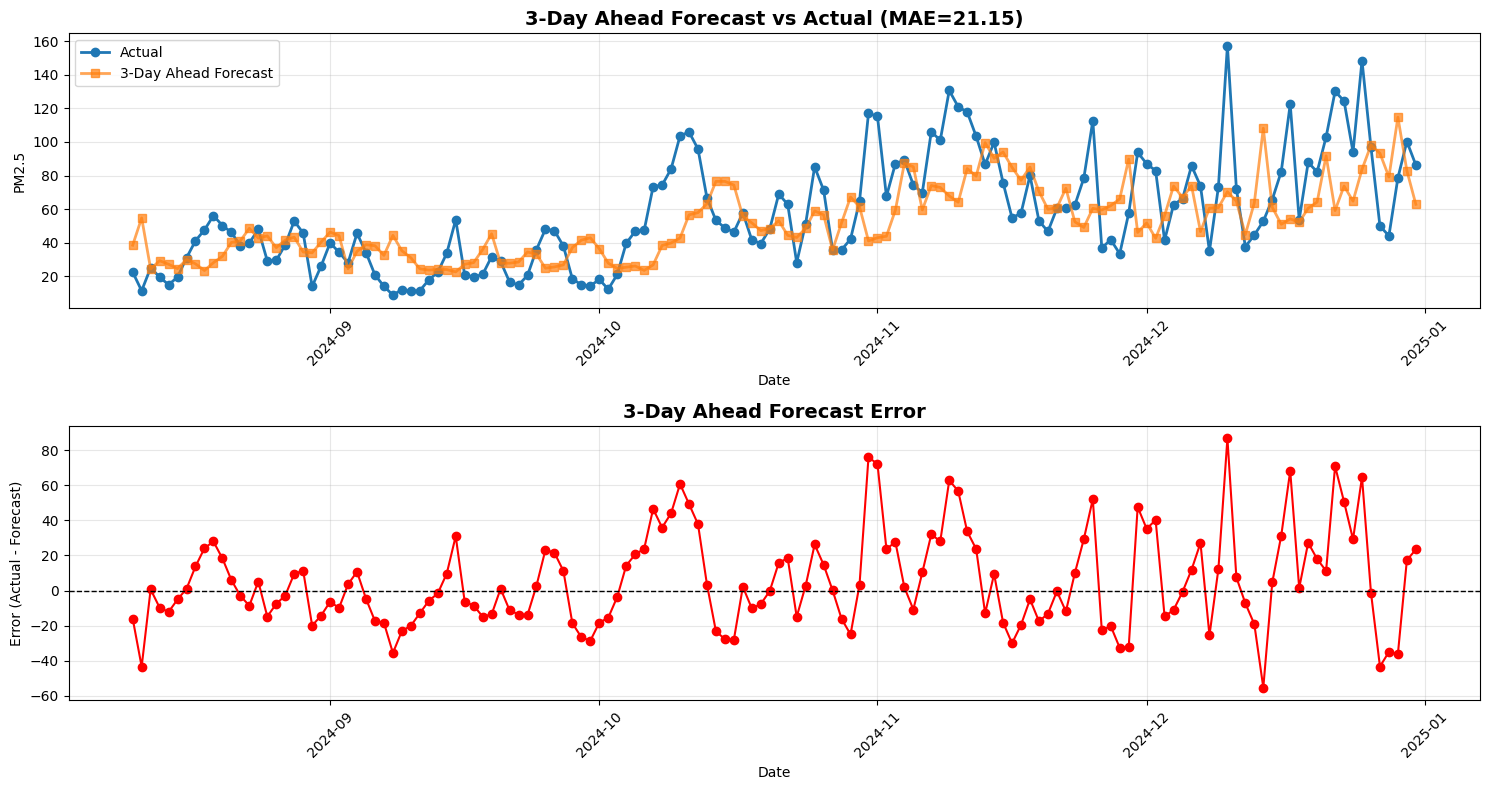

In [ ]:
import matplotlib.pyplot as plt

# Plot kết quả dự báo 3 ngày
plt.figure(figsize=(15, 8))

# Plot 1: So sánh Actual vs Forecast cho Day-3
plt.subplot(2, 1, 1)
plt.plot(results['Date'], results['Actual_Day3'], 'o-', label='Actual', linewidth=2)
plt.plot(results['Date'], results['Forecast_Day3'], 's-', label='3-Day Ahead Forecast', linewidth=2, alpha=0.7)
plt.title(f'3-Day Ahead Forecast vs Actual (MAE={mae_day3:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Plot 2: Forecast Error
plt.subplot(2, 1, 2)
plt.plot(results['Date'], results['Error_Day3'], 'ro-', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('3-Day Ahead Forecast Error', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Forecast)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [69]:

# Đọc file test
df_test = pd.read_csv(r"E:\Document\PROJECT_1\data\data_test.csv")

# Chuẩn hóa cột thời gian
df_test['Local Time'] = pd.to_datetime(df_test['Local Time'])
df_test = df_test.set_index('Local Time').sort_index()

# Lấy cột PM2.5, trung bình theo ngày, nội suy giá trị thiếu
df_pm25_test = df_test[['PM25']].resample('D').mean().asfreq('D').interpolate()

df_pm25_test.shape

(304, 1)

Official Test MAE: 16.93


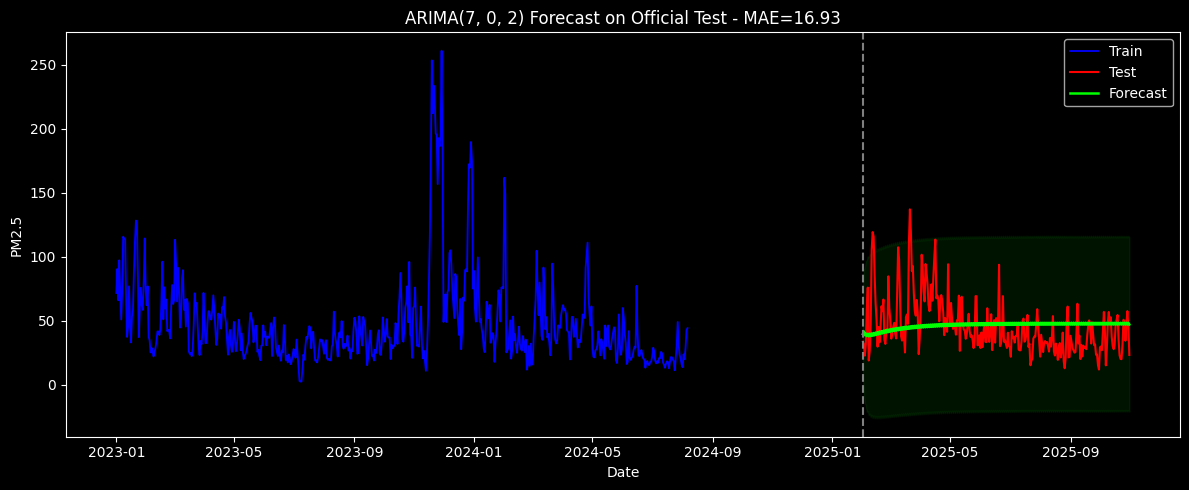

In [31]:
# Mô hình tốt nhất đã chọn
best_order = (7, 0, 2)

# Huấn luyện mô hình trên toàn bộ dữ liệu TRAIN
model = ARIMA(df_pm25_train, order=best_order).fit()

# Dự báo với độ dài bằng test mới
steps = len(df_pm25_test)
forecast_result = model.get_forecast(steps=steps)
y_pred = forecast_result.predicted_mean
y_pred.index = df_pm25_test.index
ci = forecast_result.conf_int(alpha=0.05)
ci.index = df_pm25_test.index

# MAE trên tập test chính thức
mae_test = mean_absolute_error(df_pm25_test, y_pred)  
print("Official Test MAE:", round(mae_test, 2))

plt.style.use('dark_background')
plt.figure(figsize=(12,5))

# Train
plt.plot(df_pm25_train.index, df_pm25_train, color='blue', label='Train', linewidth=1.3) 

# Test thật
plt.plot(df_pm25_test.index, df_pm25_test, color='red', label='Test', linewidth=1.5) 

# Forecast
plt.plot(y_pred.index, y_pred, color='lime', label='Forecast', linewidth=1.8)
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='green', alpha=0.15)

plt.axvline(df_pm25_test.index[0], color='gray', linestyle='--')
plt.title(f"ARIMA{best_order} Forecast on Official Test - MAE={mae_test:.2f}")
plt.xlabel("Date"); plt.ylabel("PM2.5")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [32]:
model_d0 = ARIMA(df_pm25_train, order=(7, 0, 2)).fit()
model_d1 = ARIMA(df_pm25_train, order=(7, 1, 2)).fit()

forecast_d0 = model_d0.get_forecast(steps=len(df_pm25_test)).predicted_mean
forecast_d1 = model_d1.get_forecast(steps=len(df_pm25_test)).predicted_mean

print("MAE d=0:", mean_absolute_error(df_pm25_test, forecast_d0))
print("MAE d=1:", mean_absolute_error(df_pm25_test, forecast_d1))

MAE d=0: 16.92693383336038
MAE d=1: 19.348221074672377


## Kiểm tra yếu tố mùa vụ

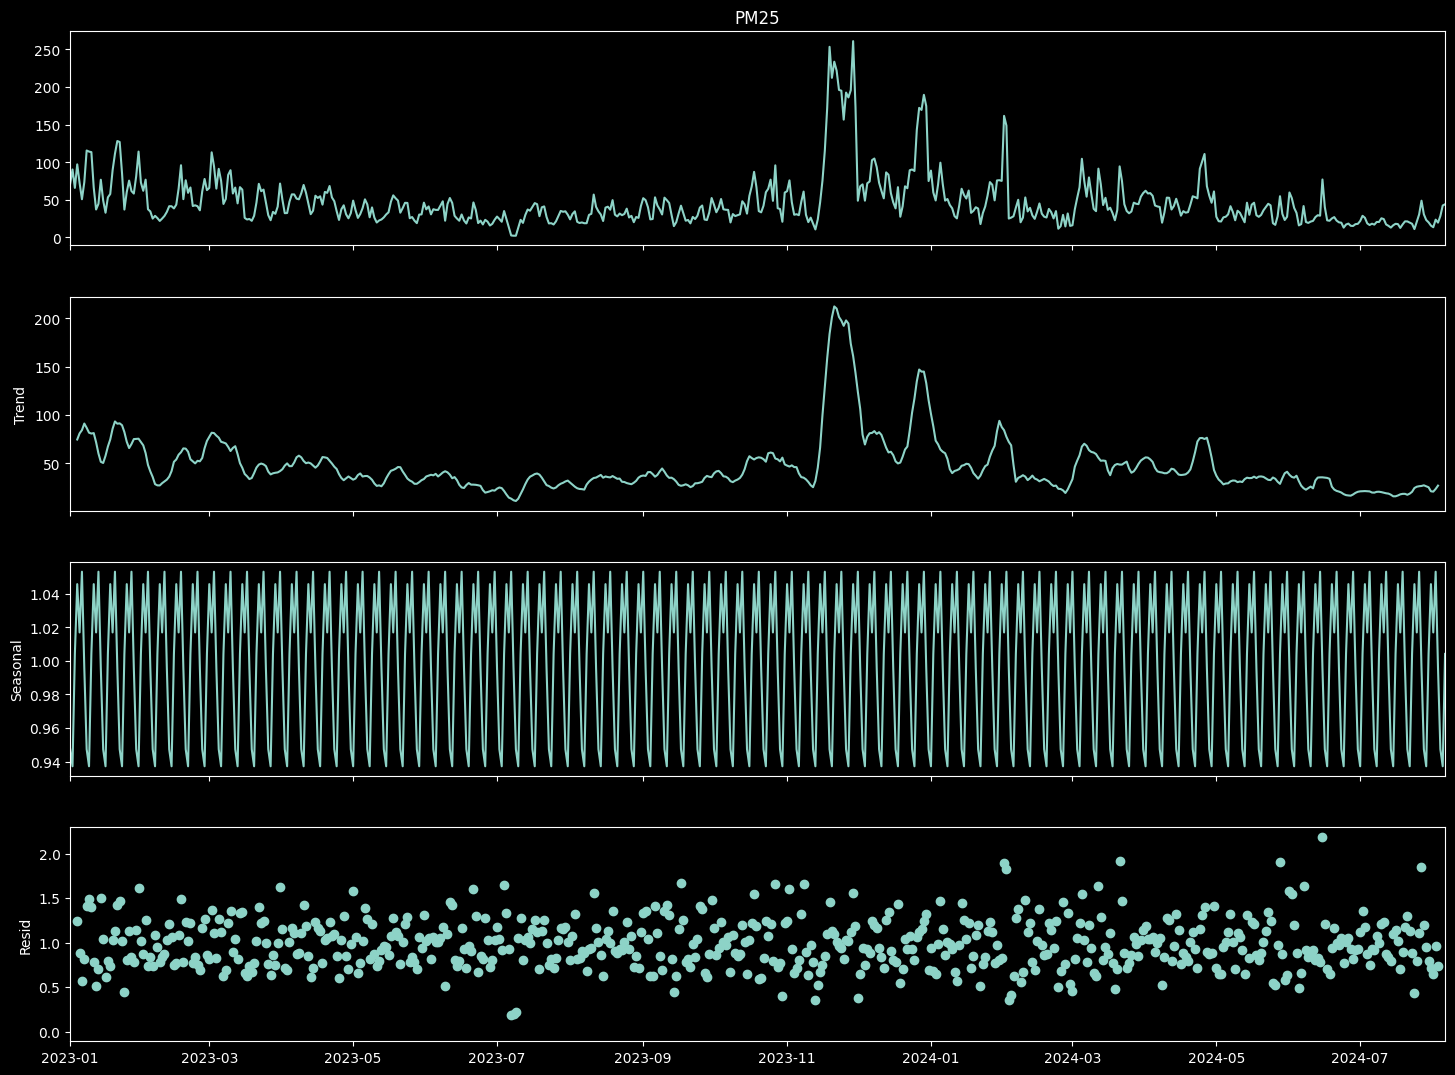

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_pm25_train, model='multiplicative')
fig = result.plot()
fig.set_size_inches(16,12)

In [34]:
import time
import pandas as pd
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Định nghĩa tham số (bạn cần thêm vào)
p_params = range(0, 3)
q_params = range(0, 3)
P_params = range(0, 2)
Q_params = range(0, 2)
D = 0  # Seasonal differencing
m = 7  # Chu kỳ theo tuần (daily data)

# Danh sách lưu kết quả
results = []

# Tổng số model cần train
total_models = len(p_params) * len(q_params) * len(P_params) * len(Q_params)
current = 0

print(f"Starting SARIMA Grid Search...")
print(f"Total models to train: {total_models}")
print("="*80 + "\n")

for p in p_params:
    for q in q_params:
        for P in P_params:
            for Q in Q_params:
                current += 1
                order = (p, 0, q)
                seasonal_order = (P, D, Q, m)

                try:
                    t0 = time.time()
                    model = SARIMAX(
                        df_pm25_train,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False)
                    elapsed = round(time.time() - t0, 2)

                    # Dự báo in-sample
                    yhat = model.fittedvalues
                    # Align lengths
                    train_aligned = df_pm25_train.iloc[-len(yhat):]
                    mae = mean_absolute_error(train_aligned, yhat)

                    # Lưu kết quả
                    results.append({
                        'p': p, 'q': q, 'P': P, 'Q': Q,
                        'order': order,
                        'seasonal_order': seasonal_order,
                        'AIC': model.aic,
                        'BIC': model.bic,
                        'MAE': mae,
                        'train_time': elapsed,
                        'converged': True
                    })

                    print(f"[{current}/{total_models}] ✓ SARIMA{order}x{seasonal_order}: "
                          f"AIC={model.aic:.2f}, MAE={mae:.2f}, Time={elapsed}s")

                except Exception as e:
                    results.append({
                        'p': p, 'q': q, 'P': P, 'Q': Q,
                        'order': order,
                        'seasonal_order': seasonal_order,
                        'AIC': None,
                        'BIC': None,
                        'MAE': None,
                        'train_time': None,
                        'converged': False
                    })
                    print(f"[{current}/{total_models}] ✗ SARIMA{order}x{seasonal_order}: {str(e)[:50]}...")

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

# Lọc các model thành công
successful_models = results_df[results_df['converged'] == True].copy()

if len(successful_models) > 0:
    # Sắp xếp theo AIC
    successful_models = successful_models.sort_values('AIC')

    print("\n" + "="*80)
    print("GRID SEARCH COMPLETED!")
    print("="*80)
    print(f"Total models attempted: {total_models}")
    print(f"Successfully trained: {len(successful_models)}")
    print(f"Failed: {len(results_df) - len(successful_models)}")

    print("\n" + "="*80)
    print("TOP 10 MODELS BY AIC:")
    print("="*80)
    top10 = successful_models.head(10)[['order', 'seasonal_order', 'AIC', 'BIC', 'MAE', 'train_time']]
    print(top10.to_string(index=False))

    print("\n" + "="*80)
    print("BEST MODEL:")
    print("="*80)
    best = successful_models.iloc[0]
    print(f"Order: {best['order']}")
    print(f"Seasonal Order: {best['seasonal_order']}")
    print(f"AIC: {best['AIC']:.2f}")
    print(f"BIC: {best['BIC']:.2f}")
    print(f"MAE: {best['MAE']:.2f}")
    print(f"Training Time: {best['train_time']}s")
    print("="*80)


else:
    print("\n No models converged successfully!")

Starting SARIMA Grid Search...
Total models to train: 36

[1/36] ✓ SARIMA(0, 0, 0)x(0, 0, 0, 7): AIC=6411.88, MAE=47.51, Time=0.01s
[2/36] ✓ SARIMA(0, 0, 0)x(0, 0, 1, 7): AIC=6013.46, MAE=32.52, Time=0.05s
[3/36] ✓ SARIMA(0, 0, 0)x(1, 0, 0, 7): AIC=5788.02, MAE=23.20, Time=0.02s
[4/36] ✓ SARIMA(0, 0, 0)x(1, 0, 1, 7): AIC=5662.16, MAE=20.71, Time=0.09s
[5/36] ✓ SARIMA(0, 0, 1)x(0, 0, 0, 7): AIC=5817.88, MAE=27.26, Time=0.04s
[6/36] ✓ SARIMA(0, 0, 1)x(0, 0, 1, 7): AIC=5576.41, MAE=23.04, Time=0.11s
[7/36] ✓ SARIMA(0, 0, 1)x(1, 0, 0, 7): AIC=5435.38, MAE=18.55, Time=0.06s
[8/36] ✓ SARIMA(0, 0, 1)x(1, 0, 1, 7): AIC=5264.63, MAE=15.95, Time=0.19s
[9/36] ✓ SARIMA(0, 0, 2)x(0, 0, 0, 7): AIC=5524.33, MAE=20.58, Time=0.07s
[10/36] ✓ SARIMA(0, 0, 2)x(0, 0, 1, 7): AIC=5373.50, MAE=19.48, Time=0.16s
[11/36] ✓ SARIMA(0, 0, 2)x(1, 0, 0, 7): AIC=5328.58, MAE=17.11, Time=0.09s
[12/36] ✓ SARIMA(0, 0, 2)x(1, 0, 1, 7): AIC=5144.80, MAE=14.67, Time=0.28s
[13/36] ✓ SARIMA(1, 0, 0)x(0, 0, 0, 7): AIC=5092.74

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_order = (2, 0, 2)
best_seasonal_order = (0, 0, 1, 7)

# Huấn luyện lại mô hình
model_best = SARIMAX(
    df_pm25_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# In kết quả chi tiết
print(model_best.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                PM25   No. Observations:                  584
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 7)   Log Likelihood               -2484.870
Date:                             Thu, 06 Nov 2025   AIC                           4981.740
Time:                                     12:31:49   BIC                           5007.856
Sample:                                 01-01-2023   HQIC                          4991.926
                                      - 08-06-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7149      0.030     56.518      0.000       1.655       1.774
ar.L2         -0.7158      

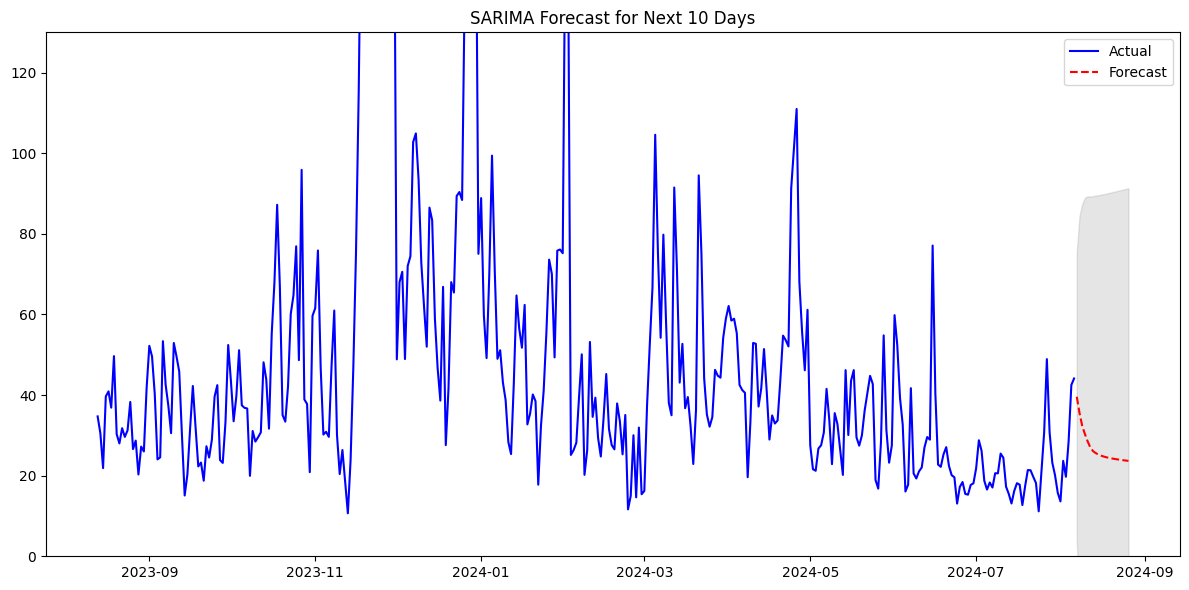

                                      SARIMAX Results                                      
Dep. Variable:                                PM25   No. Observations:                  584
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 7)   Log Likelihood               -2484.870
Date:                             Thu, 06 Nov 2025   AIC                           4981.740
Time:                                     12:31:50   BIC                           5007.856
Sample:                                 01-01-2023   HQIC                          4991.926
                                      - 08-06-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7149      0.030     56.518      0.000       1.655       1.774
ar.L2         -0.7158      

In [36]:

plt.style.use('default')

# 1) Lấy Series train (đảm bảo có tần suất ngày)
y_train = (df_pm25_train['PM25'] if hasattr(df_pm25_train, 'columns') else df_pm25_train).asfreq('D')

# 2) Lấy tham số tốt nhất từ bảng 'best' (kết quả grid search)
best_order = tuple(best['order'])                 # ví dụ (2, 0, 2)
best_seasonal = tuple(best['seasonal_order'])     # ví dụ (0, 0, 1, 7)

# 3) Fit lại mô hình tốt nhất
model_best = SARIMAX(
    y_train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 4) Dự báo n bước tới (ví dụ 10 ngày)
n_pred_periods = 20
fc_res = model_best.get_forecast(steps=n_pred_periods)
y_fc = fc_res.predicted_mean                      # Series có index thời gian
ci = fc_res.conf_int(alpha=0.05)                  # DataFrame [lower, upper]

# 5) Vẽ
plt.figure(figsize=(12,6))
plt.plot(y_train[-360:], label='Actual', color='blue')   # 360 ngày gần nhất
plt.plot(y_fc.index, y_fc, color='red', linestyle='--', label='Forecast')
plt.fill_between(y_fc.index, ci.iloc[:,0], ci.iloc[:,1], color='grey', alpha=0.2)
plt.ylim((0, 130))
plt.title('SARIMA Forecast for Next 10 Days')
plt.legend()
plt.tight_layout()
plt.show()

# (Tuỳ chọn) In bảng summary
print(model_best.summary())
